# Phase 2 — Notebook 02 · Design B (DeepSets-CNN) on E1, Stage 2.1

**Scope.** Same data, same session, same five `GroupKFold` folds as notebook 01, but the **architecture is Design B** from `PHASE2_PLANNING.md` §6.3:

$$
e_{i,h} = \text{Encoder}(x_{i,h}) \quad\quad e_i = \text{Pool}_h(e_{i,h}) \quad\quad p_i(y) = \text{Classifier}(e_i)
$$

**Why this matters.** Notebook 01 (Design A) trained a row-level CNN and averaged probabilities at evaluation: bal-acc ≈ 0.485 in *every* condition (raw, baseline-subtracted, time-shuffled, amplitude-only). The §10 reading is *AMPLITUDE-EQUIVALENT*: the row-level CNN essentially behaves as a per-trace mean readout. Design B changes the **training objective** — one cross-entropy *per neuron*, computed on a pooled embedding — so the trace encoder is optimised directly for the neuron-level representation. By construction it is permutation-invariant in the hash dimension and never averages traces across different stimuli (planning §2.3, §6.3).

**Methodological contract** (binding rules):

1. **Same population**, mismatch removed (planning §1.3).
2. **Same session 5_6** (planning §1.4).
3. **Same E1 representation** (one row per `(neuron, hash)`; planning §2.2).
4. **Same 5 GKF folds by `nucleus_id`** as notebook 01 (the `GroupKFold` partition is deterministic given the same neuron set, so paired Design-A vs Design-B comparisons are exact at the fold level).
5. **Same four conditions**: `raw_identity`, `baseline_sub_identity`, `raw_time_shuffled`, `raw_amplitude_only` (planning §4, §5). Controls are applied **per (neuron, hash) trace** so the input distribution is identical to notebook 01.
6. **Architecture**: trace encoder = same Conv1d(1→32→64) + masked GAP backbone as Design A (so any Design-A vs Design-B difference is attributable to *training objective and pool location*, not the encoder family). DeepSets-style **mean-pool over the 116 hashes** then 64→64→4 classifier head.
7. **Training**: class-weighted CE on **unique training neurons**, AdamW (lr=1e-3, wd=1e-4), CosineAnnealingLR, neuron-batch size 32, max 80 epochs, patience 12 on val neuron-level balanced accuracy.
8. **Scoring**: Design B already outputs **one prediction per neuron** — no row aggregation needed.
9. **Benchmarks (Tier G, Tier A, …) deferred** to the end-of-Phase-2 benchmark notebook.

**Comparison axes.** Same three Δ statistics as notebook 01 (Δ_baseline, Δ_temporal, Δ_amplitude) plus a new *Design A vs Design B* paired Δ on the same folds × conditions.

Outputs are saved to `data/processed/results/phase2_stage2_1_design_b_e1.parquet`.

## 0 · Environment

In [1]:
import os, sys, time, warnings
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import GroupKFold

from src.config import PROCESSED_RESULTS_DIR
from src.data.loaders import load_working_pop
from src.features.raw_traces import (
    remove_mismatch_neurons,
    build_single_session_e1,
    baseline_subtract_traces,
    MAX_TRACE_LEN,
)
from src.models.cnn import LAYER_CLASSES
from src.models.cnn_deepsets import (
    DeepSetsTraceCNN,
    build_e1_neuron_tensors,
    apply_control_to_set_tensor,
    train_design_b_fold,
    predict_neuron_proba,
    neuron_score_design_b,
)
from src.eval.cnn_eval import save_results, make_result_row

warnings.filterwarnings('ignore', category=UserWarning)

SEED       = 42
N_FOLDS    = 5
SESSION    = '5_6'
N_BASELINE = 5             # ≈ 0.67 s pre-stim @ 7.5 Hz (matches notebook 01)
MAX_EPOCHS = 80
PATIENCE   = 12
BATCH_SIZE = 32            # neurons per batch
EMBED_DIM  = 64

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device       : {DEVICE}')
print(f'Project root : {PROJECT_ROOT}')
print(f'Pad length T : {MAX_TRACE_LEN}')
print(f'CV protocol  : GroupKFold(n_splits={N_FOLDS}) by nucleus_id  (matches notebook 01)')
print(f'Architecture : DeepSetsTraceCNN(embed_dim={EMBED_DIM}, pool=\'mean\')')
print(f'Seed         : {SEED}')

Device       : mps
Project root : /Users/katiarusso/Documents/VS CODE/Classes/Neuroscience/Final Project
Pad length T : 113
CV protocol  : GroupKFold(n_splits=5) by nucleus_id  (matches notebook 01)
Architecture : DeepSetsTraceCNN(embed_dim=64, pool='mean')
Seed         : 42


## 1 · Population & session — replicate the notebook-01 setup

In [2]:
units_raw = load_working_pop()
units_clean, mismatch_report = remove_mismatch_neurons(units_raw, verbose=False)
print(f"Population (after mismatch removal): {mismatch_report['n_clean']} / {mismatch_report['n_total']} "
      f"neurons ({100 - mismatch_report['pct_removed']:.1f}%)")

df_session = build_single_session_e1(SESSION, units_clean, verbose=False)

# Sanity contracts (same as notebook 01)
assert df_session['response_avg'].notna().all()
assert set(df_session['layer_label']).issubset({'L2/3','L4','L5','L6'})
cov = df_session.groupby('nucleus_id')['condition_hash'].nunique()
assert (cov == 116).all(), f'oracle coverage not 116 for some neurons: min={cov.min()}'

n_neurons = df_session['nucleus_id'].nunique()
print(f'Session {SESSION}: {n_neurons} neurons, {len(df_session):,} (neuron × hash) rows')
print('\nLayer distribution (per neuron):')
print(df_session.drop_duplicates('nucleus_id')['layer_label'].value_counts().sort_index().to_string())

Population (after mismatch removal): 8488 / 8895 neurons (95.4%)
Session 5_6: 685 neurons, 79,460 (neuron × hash) rows

Layer distribution (per neuron):
layer_label
L2/3    151
L4      249
L5      189
L6       96


## 2 · CV folds — identical partition to notebook 01

We rebuild the same `GroupKFold(n_splits=5)` partition. Because `groups = nucleus_id` (one neuron per group) and `GroupKFold.split` is deterministic in the order of the unique groups, this re-creates exactly the per-fold neuron sets used in notebook 01. The Design-A vs Design-B Δ in §10 below is therefore paired at the fold-and-neuron level.

In [3]:
neurons_df = df_session[['nucleus_id', 'layer_label']].drop_duplicates().reset_index(drop=True)
neuron_ids = neurons_df['nucleus_id'].to_numpy()

gkf = GroupKFold(n_splits=N_FOLDS)
fold_of_neuron = np.full(len(neuron_ids), -1, dtype=np.int8)
for k, (_, te_idx) in enumerate(gkf.split(neuron_ids, groups=neuron_ids)):
    fold_of_neuron[te_idx] = k
assert (fold_of_neuron >= 0).all()
neurons_df['gkf_fold'] = fold_of_neuron

fold_layer_counts = (
    neurons_df.groupby(['gkf_fold', 'layer_label']).size().unstack(fill_value=0)
)
print('Neurons per fold × layer:')
print(fold_layer_counts.to_string())
assert (fold_layer_counts > 0).all().all()

df_session = df_session.merge(neurons_df[['nucleus_id', 'gkf_fold']], on='nucleus_id', how='left')

Neurons per fold × layer:
layer_label  L2/3  L4  L5  L6
gkf_fold                     
0              32  50  36  19
1              29  51  37  20
2              29  52  37  19
3              29  49  40  19
4              32  47  39  19


## 3 · Pack E1 rows into per-neuron set-tensors

We build the Design-B set-tensor for the **whole session once**, in two flavours: the `raw` representation and the `baseline_sub` representation (so baseline subtraction is computed once on the full session and reused across folds — equivalent to applying it per-fold because subtraction uses only the trace's own pre-stimulus window). Time-shuffle and amplitude-only controls are applied per (neuron, hash, T) trace at fold time so the per-fold seeding stays clean.

Returned shapes: `X` and `mask` have shape `(N_neurons, H=116, T=113)` (float32), `y_str` has shape `(N_neurons,)`, `nids` has shape `(N_neurons,)`.

In [4]:
# `build_e1_neuron_tensors` sorts by (nucleus_id, condition_hash) so the
# returned `nids` matches the row order of X / mask / y_str.
X_raw, mask, y_str, nids = build_e1_neuron_tensors(df_session, pad_to=MAX_TRACE_LEN)

df_session_bs = baseline_subtract_traces(df_session, n_baseline_frames=N_BASELINE)
X_bs,  _,    y_str_bs, nids_bs = build_e1_neuron_tensors(df_session_bs, pad_to=MAX_TRACE_LEN)

# Contracts: same neuron ordering and labels in both flavours
assert np.array_equal(nids, nids_bs), 'neuron ordering differs between raw and bs'
assert np.array_equal(y_str, y_str_bs), 'labels differ between raw and bs'

# Map nucleus_id → fold (using the same neurons_df partition)
fold_lookup = neurons_df.set_index('nucleus_id')['gkf_fold'].to_dict()
fold_of = np.array([fold_lookup[int(n)] for n in nids], dtype=np.int8)

print(f'X_raw  : {X_raw.shape}  dtype={X_raw.dtype}')
print(f'X_bs   : {X_bs.shape}   dtype={X_bs.dtype}')
print(f'mask   : {mask.shape}   dtype={mask.dtype}  (sum/N = {mask.sum() / np.prod(mask.shape):.3f} valid)')
print(f'y_str  : {y_str.shape}  unique = {sorted(set(y_str.tolist()))}')
print(f'fold_of: {fold_of.shape}  counts = {dict(zip(*np.unique(fold_of, return_counts=True)))}')

X_raw  : (685, 116, 113)  dtype=float32
X_bs   : (685, 116, 113)   dtype=float32
mask   : (685, 116, 113)   dtype=float32  (sum/N = 0.722 valid)
y_str  : (685,)  unique = ['L2/3', 'L4', 'L5', 'L6']
fold_of: (685,)  counts = {0: 137, 1: 137, 2: 137, 3: 137, 4: 137}


## 4 · Per-fold runner — train one Design-B model on one condition

* `normalization` selects the input flavour (`raw` or `baseline_sub`) — this picks `X_raw` vs `X_bs`.
* `control` is applied **after** the input flavour is chosen, on a copy of the train/val/test set-tensor, so the model trains and is evaluated on the same control regime.
* The validation fold for early stopping is `(test_fold + 1) mod 5` (same convention as notebook 01).

In [5]:
def run_design_b_fold(
    fold_k: int,
    *,
    normalization: str,    # 'raw' | 'baseline_sub'
    control: str,          # 'identity' | 'time_shuffled' | 'amplitude_only'
    seed: int,
    verbose: bool = False,
):
    val_k = (fold_k + 1) % N_FOLDS

    # Pick the input flavour first, then the per-fold split, then the control
    if   normalization == 'raw':          X_full, mask_full = X_raw, mask
    elif normalization == 'baseline_sub': X_full, mask_full = X_bs,  mask
    else:
        raise ValueError(f'unknown normalization: {normalization!r}')

    test_idx  = np.where(fold_of == fold_k)[0]
    val_idx   = np.where(fold_of == val_k)[0]
    train_idx = np.where(~np.isin(fold_of, [fold_k, val_k]))[0]

    # Leakage assertion (no neuron in two splits)
    assert not (set(train_idx) & set(val_idx)) and not (set(train_idx) & set(test_idx)) \
        and not (set(val_idx) & set(test_idx)), 'neuron leakage detected'

    X_tr  = X_full[train_idx]; M_tr = mask_full[train_idx]; y_tr = y_str[train_idx]
    X_va  = X_full[val_idx];   M_va = mask_full[val_idx];   y_va = y_str[val_idx]
    X_te  = X_full[test_idx];  M_te = mask_full[test_idx];  y_te = y_str[test_idx]

    # Apply the trace control (per (neuron, hash) trace) to all three splits
    X_tr = apply_control_to_set_tensor(X_tr, control, seed=seed + fold_k)
    X_va = apply_control_to_set_tensor(X_va, control, seed=seed + fold_k + 100)
    X_te = apply_control_to_set_tensor(X_te, control, seed=seed + fold_k + 200)

    model, history = train_design_b_fold(
        X_tr, M_tr, y_tr,
        X_va, M_va, y_va,
        in_channels=1, n_classes=4,
        embed_dim=EMBED_DIM, head_hidden=64, dropout=0.25, kernel_size=5,
        pool='mean',
        batch_size=BATCH_SIZE,
        max_epochs=MAX_EPOCHS, patience=PATIENCE,
        lr=1e-3, weight_decay=1e-4,
        seed=seed + fold_k,
        device=DEVICE,
        verbose=verbose,
    )

    neuron_probs = predict_neuron_proba(model, X_te, mask=M_te,
                                        batch_size=BATCH_SIZE, device=DEVICE)
    score = neuron_score_design_b(y_te, neuron_probs, classes=np.array(LAYER_CLASSES))
    return score, history

print('Design-B per-fold runner ready.')

Design-B per-fold runner ready.


## 5 · Run all four conditions × 5 folds (Design B)

Same set of conditions as notebook 01 so condition deltas (§7) and Design-A-vs-Design-B paired deltas (§10) are directly comparable.

In [6]:
CONDITIONS = [
    # (label, normalization, control)
    ('raw_identity',          'raw',          'identity'),
    ('baseline_sub_identity', 'baseline_sub', 'identity'),
    ('raw_time_shuffled',     'raw',          'time_shuffled'),
    ('raw_amplitude_only',    'raw',          'amplitude_only'),
]

results_b   = {label: [] for label, *_ in CONDITIONS}
histories_b = {label: [] for label, *_ in CONDITIONS}

t0 = time.time()
for label, norm, ctrl in CONDITIONS:
    print(f'\n────────────────────  Design B · {label}  ────────────────────')
    for k in range(N_FOLDS):
        ti = time.time()
        score, hist = run_design_b_fold(
            fold_k=k, normalization=norm, control=ctrl,
            seed=SEED, verbose=False,
        )
        score['fold'] = k
        results_b[label].append(score)
        histories_b[label].append(hist)
        ba  = score['balanced_accuracy']
        f1  = score['macro_f1']
        pcr = score['per_class_recall']
        print(f'  fold {k} | n_test={score["n_neurons"]:3d} | bal_acc={ba:.4f} '
              f'| macro-F1={f1:.4f} | recall: '
              + ' '.join(f'{c}={pcr[c]:.2f}' for c in LAYER_CLASSES)
              + f'  ({time.time() - ti:.1f}s)')
print(f'\nTotal training time: {(time.time() - t0) / 60:.1f} min')


────────────────────  Design B · raw_identity  ────────────────────
  fold 0 | n_test=137 | bal_acc=0.5324 | macro-F1=0.4672 | recall: L2/3=0.03 L4=0.54 L5=0.61 L6=0.95  (36.1s)
  fold 1 | n_test=137 | bal_acc=0.4923 | macro-F1=0.4720 | recall: L2/3=0.21 L4=0.31 L5=0.65 L6=0.80  (36.3s)
  fold 2 | n_test=137 | bal_acc=0.4963 | macro-F1=0.4257 | recall: L2/3=0.00 L4=0.58 L5=0.51 L6=0.89  (34.9s)
  fold 3 | n_test=137 | bal_acc=0.5362 | macro-F1=0.5019 | recall: L2/3=0.24 L4=0.31 L5=0.65 L6=0.95  (95.6s)
  fold 4 | n_test=137 | bal_acc=0.5129 | macro-F1=0.4277 | recall: L2/3=0.00 L4=0.62 L5=0.49 L6=0.95  (52.4s)

────────────────────  Design B · baseline_sub_identity  ────────────────────
  fold 0 | n_test=137 | bal_acc=0.5289 | macro-F1=0.4504 | recall: L2/3=0.00 L4=0.56 L5=0.56 L6=1.00  (51.9s)
  fold 1 | n_test=137 | bal_acc=0.5214 | macro-F1=0.4590 | recall: L2/3=0.07 L4=0.55 L5=0.57 L6=0.90  (39.2s)
  fold 2 | n_test=137 | bal_acc=0.4760 | macro-F1=0.4245 | recall: L2/3=0.07 L4=0.4

## 6 · Summary table — mean ± std over folds (Design B)

In [7]:
def summarise(scores):
    bas = np.array([s['balanced_accuracy'] for s in scores])
    f1s = np.array([s['macro_f1']          for s in scores])
    pcr_per_fold = {c: np.array([s['per_class_recall'][c] for s in scores]) for c in LAYER_CLASSES}
    return {
        'bal_acc_mean':  bas.mean(),
        'bal_acc_std':   bas.std(ddof=0),
        'macro_f1_mean': f1s.mean(),
        'macro_f1_std':  f1s.std(ddof=0),
        **{f'recall_{c}_mean': np.nanmean(pcr_per_fold[c]) for c in LAYER_CLASSES},
        **{f'recall_{c}_std':  np.nanstd (pcr_per_fold[c]) for c in LAYER_CLASSES},
    }

summary_rows = []
for label, _, _ in CONDITIONS:
    s = summarise(results_b[label])
    summary_rows.append({
        'condition': label,
        'bal_acc':   f"{s['bal_acc_mean']:.4f} ± {s['bal_acc_std']:.4f}",
        'macro_F1':  f"{s['macro_f1_mean']:.4f} ± {s['macro_f1_std']:.4f}",
        'L2/3':      f"{s['recall_L2/3_mean']:.3f} ± {s['recall_L2/3_std']:.3f}",
        'L4':        f"{s['recall_L4_mean']:.3f} ± {s['recall_L4_std']:.3f}",
        'L5':        f"{s['recall_L5_mean']:.3f} ± {s['recall_L5_std']:.3f}",
        'L6':        f"{s['recall_L6_mean']:.3f} ± {s['recall_L6_std']:.3f}",
    })
summary_df = pd.DataFrame(summary_rows).set_index('condition')
print(f'Stage 2.1 · Design B · session {SESSION} · 5-fold GKF by nucleus_id\n')
print(summary_df.to_string())

Stage 2.1 · Design B · session 5_6 · 5-fold GKF by nucleus_id

                               bal_acc         macro_F1           L2/3             L4             L5             L6
condition                                                                                                          
raw_identity           0.5140 ± 0.0180  0.4589 ± 0.0288  0.096 ± 0.106  0.471 ± 0.134  0.582 ± 0.069  0.907 ± 0.057
baseline_sub_identity  0.5119 ± 0.0194  0.4385 ± 0.0195  0.137 ± 0.192  0.458 ± 0.205  0.504 ± 0.049  0.948 ± 0.046
raw_time_shuffled      0.5224 ± 0.0201  0.4638 ± 0.0229  0.177 ± 0.173  0.441 ± 0.180  0.554 ± 0.068  0.917 ± 0.052
raw_amplitude_only     0.5180 ± 0.0241  0.4756 ± 0.0195  0.115 ± 0.131  0.504 ± 0.102  0.567 ± 0.101  0.886 ± 0.058


## 7 · Paired condition deltas (Design B, per-fold pairing)

Same three deltas as notebook 01: positive Δ ⇒ raw retains information that the corresponding control destroys.

In [8]:
ba_per_fold = {label: np.array([s['balanced_accuracy'] for s in results_b[label]])
               for label, *_ in CONDITIONS}

delta_rows = []
pairs = [
    ('Δ_baseline   = raw − baseline_sub',  'raw_identity', 'baseline_sub_identity'),
    ('Δ_temporal   = raw − time_shuffled', 'raw_identity', 'raw_time_shuffled'),
    ('Δ_amplitude  = raw − amplitude_only','raw_identity', 'raw_amplitude_only'),
]
for name, a, b in pairs:
    d = ba_per_fold[a] - ba_per_fold[b]
    delta_rows.append({
        'comparison': name,
        'fold0': f'{d[0]:+.3f}', 'fold1': f'{d[1]:+.3f}',
        'fold2': f'{d[2]:+.3f}', 'fold3': f'{d[3]:+.3f}',
        'fold4': f'{d[4]:+.3f}',
        'mean Δ': f'{d.mean():+.4f}',
        'std Δ':  f'{d.std(ddof=0):.4f}',
        'n_pos/5': int((d > 0).sum()),
    })
delta_df = pd.DataFrame(delta_rows).set_index('comparison')
print('Design B — per-fold paired deltas (balanced accuracy):\n')
print(delta_df.to_string())

Design B — per-fold paired deltas (balanced accuracy):

                                      fold0   fold1   fold2   fold3   fold4   mean Δ   std Δ  n_pos/5
comparison                                                                                           
Δ_baseline   = raw − baseline_sub    +0.004  -0.029  +0.020  +0.029  -0.013  +0.0022  0.0213        3
Δ_temporal   = raw − time_shuffled   +0.014  -0.030  -0.003  +0.024  -0.046  -0.0084  0.0264        2
Δ_amplitude  = raw − amplitude_only  +0.026  -0.015  -0.008  -0.030  +0.006  -0.0040  0.0191        2


## 8 · Design A vs Design B — paired comparison on the same folds × conditions

We load the per-fold balanced accuracies from notebook 01 (Design A) and pair them with the corresponding Design-B values. A positive `Δ_AB = B − A` per fold is direct evidence that the DeepSets training objective extracts more information than the row-level / averaged-probabilities objective on the *same* data partition.

In [9]:
design_a_path = Path('data/processed/results/phase2_stage2_1_single_session.parquet')
if not design_a_path.exists():
    raise FileNotFoundError(f'Design A results not found at {design_a_path}. '
                            'Run notebook 01 first.')
df_A = pd.read_parquet(design_a_path)

# Keep only per-fold rows for the four matching conditions
model_lookup = {
    'raw_identity':          'CNN_E1_raw_identity',
    'baseline_sub_identity': 'CNN_E1_baseline_sub_identity',
    'raw_time_shuffled':     'CNN_E1_raw_time_shuffled',
    'raw_amplitude_only':    'CNN_E1_raw_amplitude_only',
}

ba_A_per_fold = {}
for cond, model_name in model_lookup.items():
    sub = df_A[(df_A['model_name'] == model_name) &
               (df_A['fold_or_session'].str.contains('fold'))].copy()
    sub['fold'] = sub['fold_or_session'].str.extract(r'fold(\d+)$').astype(int)
    sub = sub.sort_values('fold')
    if len(sub) != N_FOLDS:
        raise RuntimeError(f'Expected {N_FOLDS} fold rows for {cond}, got {len(sub)}')
    ba_A_per_fold[cond] = sub['balanced_accuracy'].to_numpy()

rows_AB = []
for cond in model_lookup:
    a = ba_A_per_fold[cond]
    b = ba_per_fold[cond]
    d = b - a
    rows_AB.append({
        'condition': cond,
        'A_mean':   f'{a.mean():.4f}',
        'B_mean':   f'{b.mean():.4f}',
        'Δ_AB':     f'{d.mean():+.4f}',
        'std Δ_AB': f'{d.std(ddof=0):.4f}',
        'n_pos/5':  int((d > 0).sum()),
        'per-fold Δ': '  '.join(f'{x:+.3f}' for x in d),
    })

AB_df = pd.DataFrame(rows_AB).set_index('condition')
print('Design A vs Design B — paired per-fold (balanced accuracy):\n')
print(AB_df.to_string())

Design A vs Design B — paired per-fold (balanced accuracy):

                       A_mean  B_mean     Δ_AB std Δ_AB  n_pos/5                              per-fold Δ
condition                                                                                               
raw_identity           0.4847  0.5140  +0.0294   0.0452        4  -0.040  +0.007  +0.062  +0.091  +0.028
baseline_sub_identity  0.4851  0.5119  +0.0268   0.0142        5  +0.030  +0.026  +0.001  +0.035  +0.042
raw_time_shuffled      0.4850  0.5224  +0.0374   0.0269        5  +0.008  +0.021  +0.018  +0.069  +0.071
raw_amplitude_only     0.4937  0.5180  +0.0243   0.0204        4  +0.017  +0.019  +0.033  +0.057  -0.005


## 9 · Plots — Design B bal-acc and confusion matrix; Design A vs Design B side-by-side

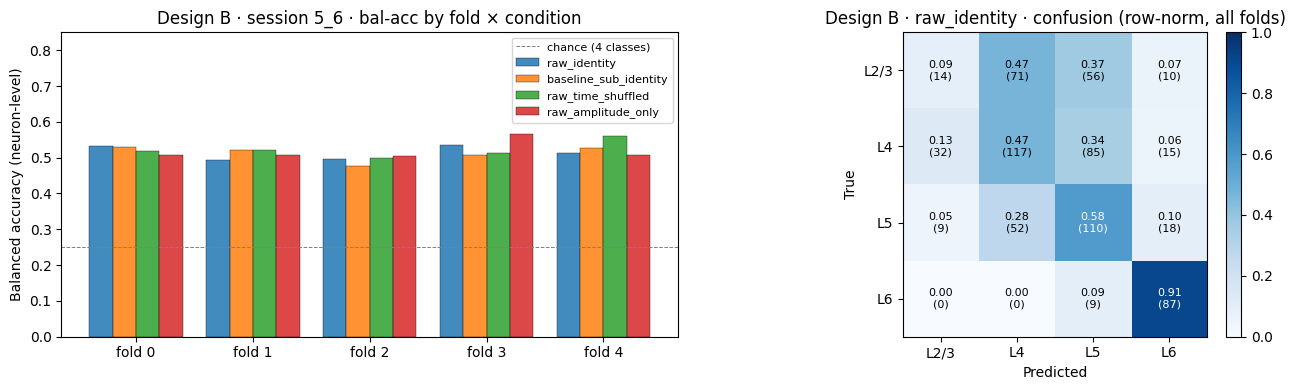

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) Per-fold bal-acc bars (Design B), conditions side-by-side
ax = axes[0]
x = np.arange(N_FOLDS)
width = 0.20
for i, (label, *_ ) in enumerate(CONDITIONS):
    ax.bar(x + (i - 1.5) * width, ba_per_fold[label], width=width,
           label=label, alpha=0.85, edgecolor='k', linewidth=0.3)
ax.axhline(0.25, color='gray', ls='--', lw=0.7, label='chance (4 classes)')
ax.set_xticks(x); ax.set_xticklabels([f'fold {k}' for k in range(N_FOLDS)])
ax.set_ylabel('Balanced accuracy (neuron-level)')
y_top = max(0.85, max(ba_per_fold[lbl].max() for lbl, *_ in CONDITIONS) + 0.05)
ax.set_ylim(0.0, y_top)
ax.set_title(f'Design B · session {SESSION} · bal-acc by fold × condition')
ax.legend(fontsize=8, loc='upper right')

# (b) raw_identity confusion (sum across folds, row-normalised)
ax = axes[1]
C = sum(s['confusion_matrix'] for s in results_b['raw_identity'])
C_norm = C / C.sum(axis=1, keepdims=True).clip(min=1)
im = ax.imshow(C_norm, vmin=0, vmax=1, cmap='Blues')
for i in range(C.shape[0]):
    for j in range(C.shape[1]):
        ax.text(j, i, f'{C_norm[i,j]:.2f}\n({C[i,j]})',
                ha='center', va='center', fontsize=8,
                color='white' if C_norm[i,j] > 0.5 else 'black')
ax.set_xticks(range(len(LAYER_CLASSES))); ax.set_xticklabels(LAYER_CLASSES)
ax.set_yticks(range(len(LAYER_CLASSES))); ax.set_yticklabels(LAYER_CLASSES)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Design B · raw_identity · confusion (row-norm, all folds)')
plt.colorbar(im, ax=ax, fraction=0.045, pad=0.03)

plt.tight_layout(); plt.show()

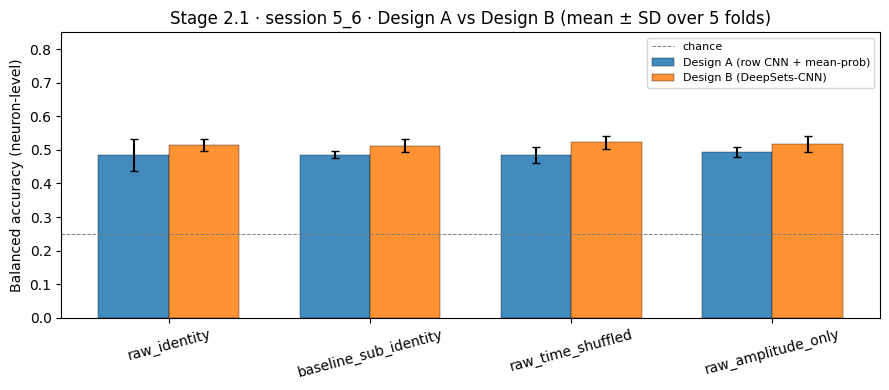

In [11]:
# (c) Design A vs Design B per condition (mean ± std across folds, paired bars)
fig, ax = plt.subplots(figsize=(9, 4))
labels = list(model_lookup.keys())
x = np.arange(len(labels))
w = 0.35

A_mean = np.array([ba_A_per_fold[c].mean()           for c in labels])
A_std  = np.array([ba_A_per_fold[c].std(ddof=0)      for c in labels])
B_mean = np.array([ba_per_fold[c].mean()             for c in labels])
B_std  = np.array([ba_per_fold[c].std(ddof=0)        for c in labels])

ax.bar(x - w/2, A_mean, w, yerr=A_std, capsize=3, label='Design A (row CNN + mean-prob)',
       color='C0', alpha=0.85, edgecolor='k', linewidth=0.3)
ax.bar(x + w/2, B_mean, w, yerr=B_std, capsize=3, label='Design B (DeepSets-CNN)',
       color='C1', alpha=0.85, edgecolor='k', linewidth=0.3)
ax.axhline(0.25, color='gray', ls='--', lw=0.7, label='chance')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('Balanced accuracy (neuron-level)')
ax.set_title(f'Stage 2.1 · session {SESSION} · Design A vs Design B (mean ± SD over 5 folds)')
ax.legend(fontsize=8)
ax.set_ylim(0.0, max(0.85, B_mean.max() + B_std.max() + 0.05))
plt.tight_layout(); plt.show()

## 10 · Training curves (Design B)

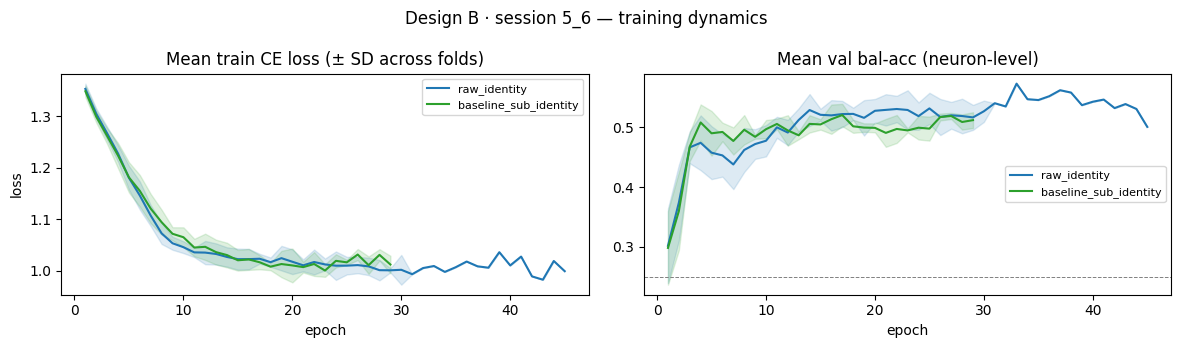

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for label, color in [('raw_identity', 'C0'), ('baseline_sub_identity', 'C2')]:
    hists = histories_b[label]
    max_e = max(len(h) for h in hists)
    loss = np.full((len(hists), max_e), np.nan)
    vacc = np.full((len(hists), max_e), np.nan)
    for i, h in enumerate(hists):
        loss[i, :len(h)] = [r['train_loss']  for r in h]
        vacc[i, :len(h)] = [r['val_bal_acc'] for r in h]
    epochs = np.arange(1, max_e + 1)
    axes[0].plot(epochs, np.nanmean(loss, 0), color=color, label=label)
    axes[0].fill_between(epochs,
                         np.nanmean(loss, 0) - np.nanstd(loss, 0),
                         np.nanmean(loss, 0) + np.nanstd(loss, 0),
                         color=color, alpha=0.15)
    axes[1].plot(epochs, np.nanmean(vacc, 0), color=color, label=label)
    axes[1].fill_between(epochs,
                         np.nanmean(vacc, 0) - np.nanstd(vacc, 0),
                         np.nanmean(vacc, 0) + np.nanstd(vacc, 0),
                         color=color, alpha=0.15)
axes[0].set(title='Mean train CE loss (± SD across folds)', xlabel='epoch', ylabel='loss')
axes[1].set(title='Mean val bal-acc (neuron-level)',         xlabel='epoch')
axes[1].axhline(0.25, color='gray', ls='--', lw=0.7)
for ax in axes:
    ax.legend(fontsize=8)
plt.suptitle(f'Design B · session {SESSION} — training dynamics')
plt.tight_layout(); plt.show()

## 11 · Interpretation (per planning §10, applied to Design B)

Same conservative thresholds as notebook 01 (`raw` is considered above-chance only if it beats 0.25 by ≥ 5 pp; a paired Δ is meaningful only if its absolute value exceeds `EPS_DELTA = 0.01`). We additionally report the Design-A-vs-Design-B Δ on `raw_identity` as a *training-objective* probe: positive ⇒ pooling at the embedding level extracts information that pooling at the probability level loses.

In [13]:
EPS_DELTA = 0.01

ba_raw  = ba_per_fold['raw_identity'].mean()
ba_bsub = ba_per_fold['baseline_sub_identity'].mean()
ba_shuf = ba_per_fold['raw_time_shuffled'].mean()
ba_amp  = ba_per_fold['raw_amplitude_only'].mean()

d_baseline  = ba_raw - ba_bsub
d_temporal  = ba_raw - ba_shuf
d_amplitude = ba_raw - ba_amp

raw_above_chance  = ba_raw  - 0.25
bsub_above_chance = ba_bsub - 0.25

d_AB_raw = ba_raw - ba_A_per_fold['raw_identity'].mean()

verdicts = []

if raw_above_chance < 0.05:
    verdicts.append('FAILURE: Design B raw CNN does not beat chance by ≥ 5 pp on this session. '
                    'The trace encoder cannot extract layer information at the neuron level even '
                    'with the correct training objective. Do NOT scale to E0 / multi-session before '
                    'examining: (i) input scaling and dynamic range; (ii) the masked-GAP behaviour '
                    'on this session; (iii) the class-weighting bias toward L6.')
else:
    verdicts.append(f'Design B raw CNN beats chance: {ba_raw:.3f} (Δ vs chance = {raw_above_chance:+.3f}).')

    # offset reliance
    if d_baseline > EPS_DELTA and bsub_above_chance < 0.03:
        verdicts.append(f'OFFSET-DRIVEN: removing baseline offset collapses Design B '
                        f'(raw {ba_raw:.3f} → bsub {ba_bsub:.3f}, Δ={d_baseline:+.3f}). '
                        f'Performance reflects within-session offset/baseline more than evoked dynamics.')
    elif abs(d_baseline) <= EPS_DELTA:
        verdicts.append(f'Offset is not the driver in Design B: baseline-subtracted ≈ raw '
                        f'(Δ_baseline={d_baseline:+.3f}).')
    elif d_baseline < -EPS_DELTA:
        verdicts.append(f'Baseline-subtracted IMPROVES over raw (Δ={d_baseline:+.3f}); '
                        f'offset is a confound that the CNN benefits from removing.')
    else:
        verdicts.append(f'Raw modestly above bsub (Δ={d_baseline:+.3f}); '
                        f'offset contributes some signal but is not the only driver.')

    # temporal order
    if d_temporal > EPS_DELTA:
        verdicts.append(f'TEMPORAL ORDER MATTERS in Design B: raw beats time-shuffled '
                        f'(Δ_temporal={d_temporal:+.3f}). The DeepSets-CNN extracts information '
                        f'from the order of frames within each trace.')
    elif abs(d_temporal) <= EPS_DELTA:
        verdicts.append(f'Temporal order does NOT contribute even under Design B: raw ≈ time-shuffled '
                        f'(Δ_temporal={d_temporal:+.3f}). The model relies on the marginal amplitude '
                        f'distribution, not response kinetics. Kinetics claims are NOT allowed.')
    else:
        verdicts.append(f'Time-shuffled is BETTER than raw (Δ_temporal={d_temporal:+.3f}); '
                        f'shuffling acts as accidental regularisation or the temporal signal is fragile.')

    # amplitude
    if d_amplitude > EPS_DELTA:
        verdicts.append(f'BEYOND AMPLITUDE in Design B: raw beats amplitude-only '
                        f'(Δ_amplitude={d_amplitude:+.3f}). The trace contributes information '
                        f'that a single scalar amplitude does not capture.')
    elif abs(d_amplitude) <= EPS_DELTA:
        verdicts.append(f'AMPLITUDE-EQUIVALENT under Design B too: raw ≈ amplitude-only '
                        f'(Δ_amplitude={d_amplitude:+.3f}). Even with the correct training '
                        f'objective, a per-trace mean is as informative as the full trace within '
                        f'this session.')
    else:
        verdicts.append(f'Amplitude-only OUTPERFORMS raw under Design B (Δ_amplitude={d_amplitude:+.3f}); '
                        f'over-fitting noise or trace-shape is actively misleading.')

    # Design A vs Design B (training objective)
    if d_AB_raw > EPS_DELTA:
        verdicts.append(f'TRAINING OBJECTIVE MATTERS: Design B beats Design A on raw_identity '
                        f'(Δ_AB={d_AB_raw:+.3f}). Pooling at the embedding level recovers '
                        f'information that pooling at the probability level lost.')
    elif abs(d_AB_raw) <= EPS_DELTA:
        verdicts.append(f'Training objective does not move the needle: Design A ≈ Design B on '
                        f'raw_identity (Δ_AB={d_AB_raw:+.3f}). The bottleneck is the *representation*, '
                        f'not the objective.')
    else:
        verdicts.append(f'Design B is WORSE than Design A on raw_identity (Δ_AB={d_AB_raw:+.3f}); '
                        f'embedding-level pooling may be over-regularising or the encoder needs '
                        f'more capacity / longer training under the new objective.')

    # Decision on next stage
    if d_temporal > EPS_DELTA and d_amplitude > EPS_DELTA and bsub_above_chance > 0.03:
        verdicts.append('PROCEED to Stage 2.2 (E0 trial-level) — Design B exposes temporal information '
                       'beyond amplitude on a single session. Run E0 with both Design A and Design B for '
                       'direct comparison. (planning §7-Stage 2.2)')
    else:
        verdicts.append('Proceeding to Stage 2.2 (E0) is still informative, but the strong cross-session '
                       'and kinetics claims of planning §11 require Δ_temporal > 0 AND Δ_amplitude > 0. '
                       'Plan saliency / occlusion before any kinetics claim. (planning §11)')

print('Stage 2.1 · Design B verdict:')
for v in verdicts:
    print('  • ' + v)

Stage 2.1 · Design B verdict:
  • Design B raw CNN beats chance: 0.514 (Δ vs chance = +0.264).
  • Offset is not the driver in Design B: baseline-subtracted ≈ raw (Δ_baseline=+0.002).
  • Temporal order does NOT contribute even under Design B: raw ≈ time-shuffled (Δ_temporal=-0.008). The model relies on the marginal amplitude distribution, not response kinetics. Kinetics claims are NOT allowed.
  • AMPLITUDE-EQUIVALENT under Design B too: raw ≈ amplitude-only (Δ_amplitude=-0.004). Even with the correct training objective, a per-trace mean is as informative as the full trace within this session.
  • TRAINING OBJECTIVE MATTERS: Design B beats Design A on raw_identity (Δ_AB=+0.029). Pooling at the embedding level recovers information that pooling at the probability level lost.
  • Proceeding to Stage 2.2 (E0) is still informative, but the strong cross-session and kinetics claims of planning §11 require Δ_temporal > 0 AND Δ_amplitude > 0. Plan saliency / occlusion before any kinetics claim

## 12 · Persist results

In [14]:
rows = []
for label, norm, ctrl in CONDITIONS:
    for k, score in enumerate(results_b[label]):
        rows.append(make_result_row(
            model_name      = f'DeepSetsCNN_E1_{label}',
            input_mode      = 'E1_set_padded_oracle',
            normalization   = norm,
            stimulus_family = 'all_padded',
            split_protocol  = f'within_session_GKF{N_FOLDS}',
            fold_or_session = f'{SESSION}_fold{k}',
            seed            = SEED + k,
            score_dict      = score,
            notes           = (f'Stage 2.1 Design B (DeepSets-CNN, mean pool); control={ctrl}; '
                               'mismatch removed; padded T=113; masked GAP per trace'),
        ))
    s = summarise(results_b[label])
    rows.append({
        'model_name':        f'DeepSetsCNN_E1_{label}',
        'input_mode':        'E1_set_padded_oracle',
        'normalization':     norm,
        'stimulus_family':   'all_padded',
        'split_protocol':    f'within_session_GKF{N_FOLDS}',
        'fold_or_session':   f'{SESSION}_summary',
        'seed':              SEED,
        'n_neurons':         int(np.mean([sc['n_neurons'] for sc in results_b[label]])),
        'balanced_accuracy': float(s['bal_acc_mean']),
        'macro_f1':          float(s['macro_f1_mean']),
        'recall_L23':        float(s['recall_L2/3_mean']),
        'recall_L4':         float(s['recall_L4_mean']),
        'recall_L5':         float(s['recall_L5_mean']),
        'recall_L6':         float(s['recall_L6_mean']),
        'notes':             (f'Stage 2.1 Design B SUMMARY (mean over {N_FOLDS} folds); '
                              f'control={ctrl}; bal_acc_std={s["bal_acc_std"]:.4f}'),
    })

save_results(rows, 'phase2_stage2_1_design_b_e1.parquet')
print(f'Saved {len(rows)} rows → data/processed/results/phase2_stage2_1_design_b_e1.parquet')

Saved 24 row(s) → data/processed/results/phase2_stage2_1_design_b_e1.parquet  (total: 24)
Saved 24 rows → data/processed/results/phase2_stage2_1_design_b_e1.parquet


---

### What this notebook does NOT claim

* **No cross-session claim.** All metrics are within session 5_6 (planning §1.2, §10).
* **No engineered-tier comparison.** Tier-G / Tier-A / multimodal benchmarks are deferred to the end-of-Phase-2 benchmark notebook.
* **No kinetics claim** unless Δ_temporal > 0, Δ_amplitude > 0, baseline-subtracted does not collapse, **and** saliency/occlusion (a future notebook) localises signal to evoked windows (planning §11).

### Next notebook (Stage 2.2 — E0 on session 5_6)

If Design B beats Design A here, Stage 2.2 will run E0 (`(neuron, hash, trial)` rows) with **both designs** and report row-uniform vs hash-uniform aggregations. If Design B is amplitude-equivalent here, Stage 2.2 still runs but the prior on temporal-information claims tightens further.